In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

In [15]:
# check sns color names
print(sns.color_palette().as_hex())

['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3', '#937860', '#da8bc3', '#8c8c8c', '#ccb974', '#64b5cd']


In [9]:
zambia_geo = pd.read_csv('../../data/Zambia_Geographic/geo_natural_resource.csv')
lic_geo = pd.read_csv('../../data/LIC_Geographic/geo_natural_resource.csv')

In [10]:
zambia_clean, zambia_lookup = clean_wb_wide(zambia_geo, drop_top_rows=0)
lic_clean, lic_lookup = clean_wb_wide(lic_geo, drop_top_rows=0)

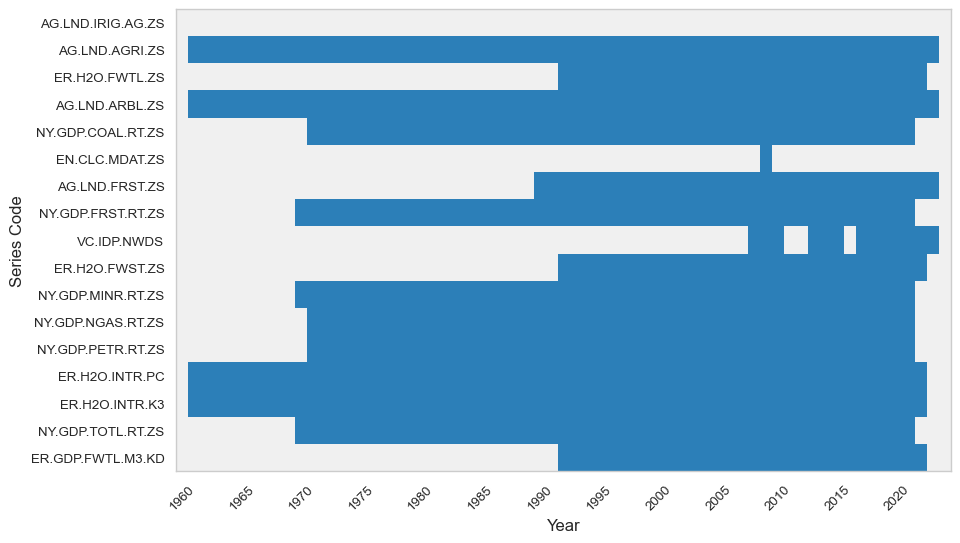

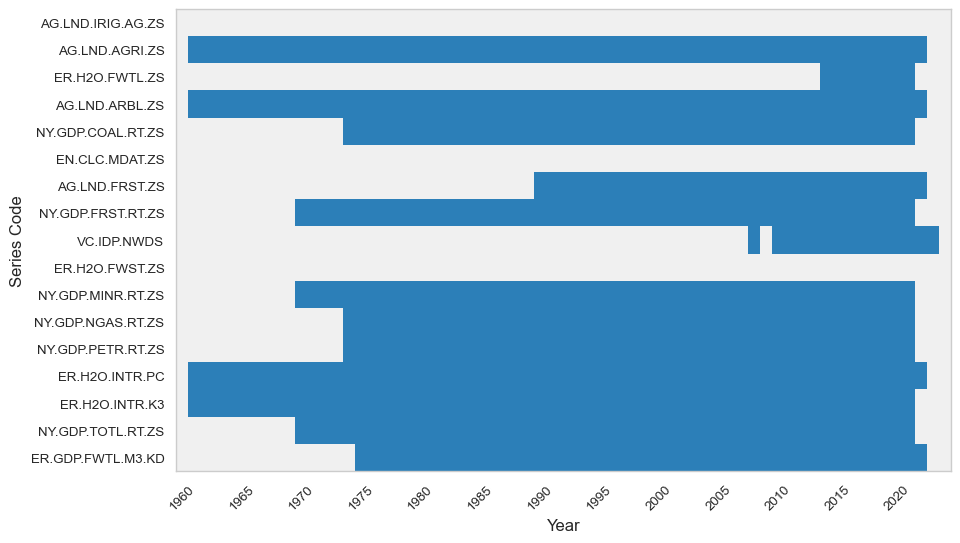

In [11]:
availability_zambia, fig_zambia, ax = plot_missing_heatmap(zambia_clean, lookup=zambia_lookup)
availability_lic, fig_lic, ax = plot_missing_heatmap(lic_clean, lookup=lic_lookup)

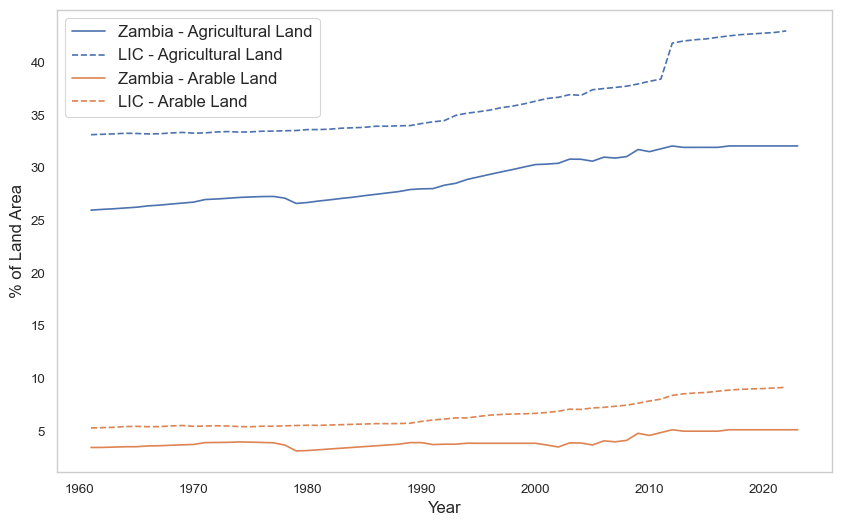

In [25]:
# percentage of arable land
df_zambia = zambia_clean.dropna(subset=['AG.LND.AGRI.ZS','AG.LND.ARBL.ZS'])
df_lic = lic_clean.dropna(subset=['AG.LND.AGRI.ZS','AG.LND.ARBL.ZS'])
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df_zambia['Year'], df_zambia['AG.LND.AGRI.ZS'],
        label= 'Zambia - Agricultural Land', color= '#4c72b0')
ax.plot(df_lic['Year'], df_lic['AG.LND.AGRI.ZS'],
        linestyle= '--', label= 'LIC - Agricultural Land', color= '#4c72b0')

ax.plot(df_zambia['Year'], df_zambia['AG.LND.ARBL.ZS'],
        label= 'Zambia - Arable Land', color= '#dd8452')
ax.plot(df_lic['Year'], df_lic['AG.LND.ARBL.ZS'],
        linestyle= '--', label= 'LIC - Arable Land', color= '#dd8452')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('% of Land Area', fontsize=12)
ax.legend(fontsize=12)
ax.grid(False)

ax.set_xlim(1958, 2026)

fig.savefig('../figures/LIC/geographic/land_use_trends.png', bbox_inches='tight')

In [22]:
print(
    make_summary_latex(
    df_zambia[['AG.LND.AGRI.ZS','AG.LND.ARBL.ZS']].describe().T,
    caption='Summary statistics of Agricultural Land and Arable Land (% of land area)',
    label='tab:land_summary_zambia')
)

\begin{table}
\caption{Summary statistics of Agricultural Land and Arable Land (% of land area)}
\label{tab:land_summary_zambia}
\begin{tabular}{rrrrrrrr}
\toprule
count & mean & std & min & 25\% & 50\% & 75\% & max \\
\midrule
63.00 & 28.97 & 2.20 & 25.97 & 27.06 & 28.34 & 31.03 & 32.07 \\
63.00 & 4.00 & 0.60 & 3.10 & 3.62 & 3.83 & 4.08 & 5.11 \\
\bottomrule
\end{tabular}
\end{table}



In [23]:
print(
    make_summary_latex(
    df_lic[['AG.LND.AGRI.ZS','AG.LND.ARBL.ZS']].describe().T,
    caption='Summary statistics of Agricultural Land and Arable Land (% of land area)',
    label='tab:land_summary_lic')
)

\begin{table}
\caption{Summary statistics of Agricultural Land and Arable Land (% of land area)}
\label{tab:land_summary_lic}
\begin{tabular}{rrrrrrrr}
\toprule
count & mean & std & min & 25\% & 50\% & 75\% & max \\
\midrule
62.00 & 36.10 & 3.34 & 33.14 & 33.47 & 34.42 & 37.60 & 42.99 \\
62.00 & 6.56 & 1.27 & 5.28 & 5.49 & 6.08 & 7.32 & 9.15 \\
\bottomrule
\end{tabular}
\end{table}



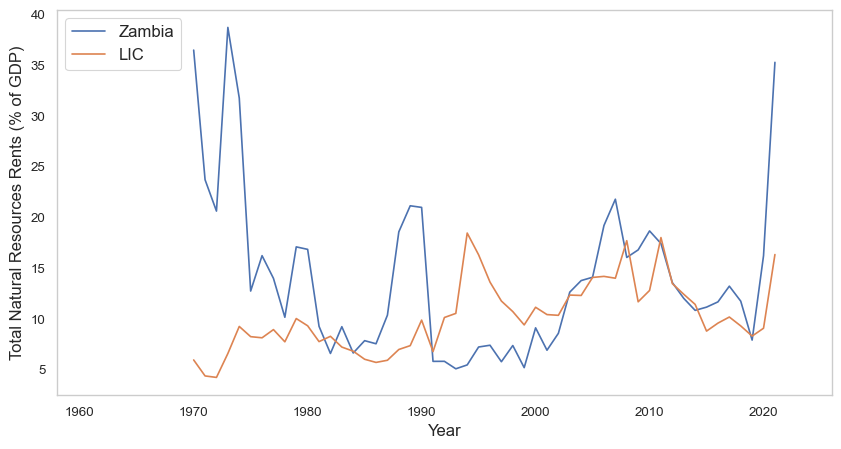

In [28]:
# df = geo_clean.dropna(subset=['NY.GDP.TOTL.RT.ZS'])
df_zambia = zambia_clean.dropna(subset=['NY.GDP.TOTL.RT.ZS'])
df_lic = lic_clean.dropna(subset=['NY.GDP.TOTL.RT.ZS'])
fig, ax = plt.subplots(figsize=(10, 5))

# ax.plot(df['Year'], df['NY.GDP.TOTL.RT.ZS'], marker='o')
ax.plot(df_zambia['Year'], df_zambia['NY.GDP.TOTL.RT.ZS'], label='Zambia')
ax.plot(df_lic['Year'], df_lic['NY.GDP.TOTL.RT.ZS'], label='LIC')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Natural Resources Rents (% of GDP)', fontsize=12)

ax.set_xlim(1958, 2026)
ax.grid(False)
ax.legend(fontsize=12)

fig.savefig(
    "../figures/LIC/geographic/total_natural_resource_rents.pdf",
    format="pdf",
    bbox_inches="tight")